In [1]:
from google.colab import files
uploaded = files.upload()


Saving retail_price.csv to retail_price.csv


In [3]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('retail_price.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (676, 30)
Columns: ['product_id', 'product_category_name', 'month_year', 'qty', 'total_price', 'freight_price', 'unit_price', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month', 'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price']


,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


In [5]:
# Basic Cleaning
print("Nulls:\n", df.isnull().sum())
print("\nDtypes:\n", df.dtypes)

# Drop bad rows
df = df[df['unit_price'] > 0]
df = df[df['qty'] > 0]

# Derived columns — using correct column names
df['revenue'] = df['unit_price'] * df['qty']
df['margin'] = df['unit_price'] - df['freight_price']
df['margin_pct'] = ((df['margin'] / df['unit_price']) * 100).round(2)

# Competitor avg using actual column names: comp_1, comp_2, comp_3
df['comp_avg'] = df[['comp_1', 'comp_2', 'comp_3']].mean(axis=1)
df['price_gap'] = (df['unit_price'] - df['comp_avg']).round(2)
df['price_position'] = df['price_gap'].apply(
    lambda x: 'Overpriced' if x > 5 else ('Underpriced' if x < -5 else 'On-par')
)

# Price bands
df['price_band'] = pd.cut(
    df['unit_price'],
    bins=[0, 50, 150, 300, 500, 99999],
    labels=['<50', '50–150', '150–300', '300–500', '500+']
)

print("\nCleaned shape:", df.shape)
print(df[['unit_price', 'qty', 'revenue', 'margin_pct', 'price_position']].describe())

Nulls:
 product_id                    0
product_category_name         0
month_year                    0
qty                           0
total_price                   0
freight_price                 0
unit_price                    0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_score                 0
customers                     0
weekday                       0
weekend                       0
holiday                       0
month                         0
year                          0
s                             0
volume                        0
comp_1                        0
ps1                           0
fp1                           0
comp_2                        0
ps2                           0
fp2                           0
comp_3                        0
ps3                           0
fp3                           0
lag_price                     0
revenue                       0


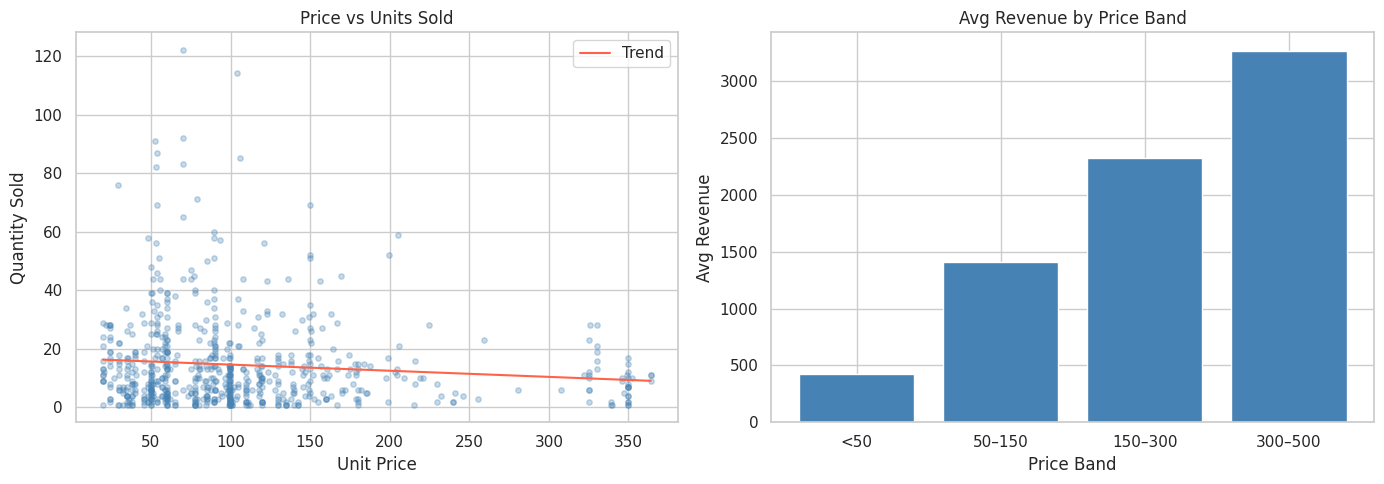

In [6]:
# Price vs Demand
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style='whitegrid', palette='muted')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: price vs qty
axes[0].scatter(df['unit_price'], df['qty'], alpha=0.3, color='steelblue', s=15)
axes[0].set_title('Price vs Units Sold')
axes[0].set_xlabel('Unit Price')
axes[0].set_ylabel('Quantity Sold')

z = np.polyfit(df['unit_price'], df['qty'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['unit_price'].min(), df['unit_price'].max(), 200)
axes[0].plot(x_line, p(x_line), color='tomato', linewidth=1.5, label='Trend')
axes[0].legend()

# Avg revenue by price band
band_rev = df.groupby('price_band', observed=True)['revenue'].mean().reset_index()
axes[1].bar(band_rev['price_band'].astype(str), band_rev['revenue'],
            color='steelblue', edgecolor='white')
axes[1].set_title('Avg Revenue by Price Band')
axes[1].set_xlabel('Price Band')
axes[1].set_ylabel('Avg Revenue')

plt.tight_layout()
plt.savefig('price_vs_demand.png', dpi=150, bbox_inches='tight')
plt.show()

In [7]:
# Price Elasticity by Category
from scipy import stats

print("=== Price Elasticity by Category ===\n")
elasticity_results = []

for cat in df['product_category_name'].dropna().unique():
    subset = df[df['product_category_name'] == cat].copy()
    if len(subset) < 10:
        continue
    log_price = np.log(subset['unit_price'] + 1)
    log_qty   = np.log(subset['qty'] + 1)
    slope, intercept, r, p_val, _ = stats.linregress(log_price, log_qty)
    elasticity_results.append({
        'category': cat,
        'elasticity': round(slope, 3),
        'r_squared': round(r**2, 3),
        'interpretation': 'Elastic' if slope < -1 else ('Inelastic' if slope > -1 else 'Unit elastic')
    })

elast_df = pd.DataFrame(elasticity_results).sort_values('elasticity')
print(elast_df.to_string(index=False))

=== Price Elasticity by Category ===

             category  elasticity  r_squared interpretation
       consoles_games      -2.008      0.304        Elastic
         garden_tools      -0.717      0.092      Inelastic
            perfumery      -0.445      0.066      Inelastic
        watches_gifts      -0.322      0.022      Inelastic
        health_beauty      -0.127      0.023      Inelastic
           cool_stuff       0.081      0.001      Inelastic
      furniture_decor       0.280      0.013      Inelastic
computers_accessories       0.348      0.009      Inelastic
       bed_bath_table       0.556      0.081      Inelastic


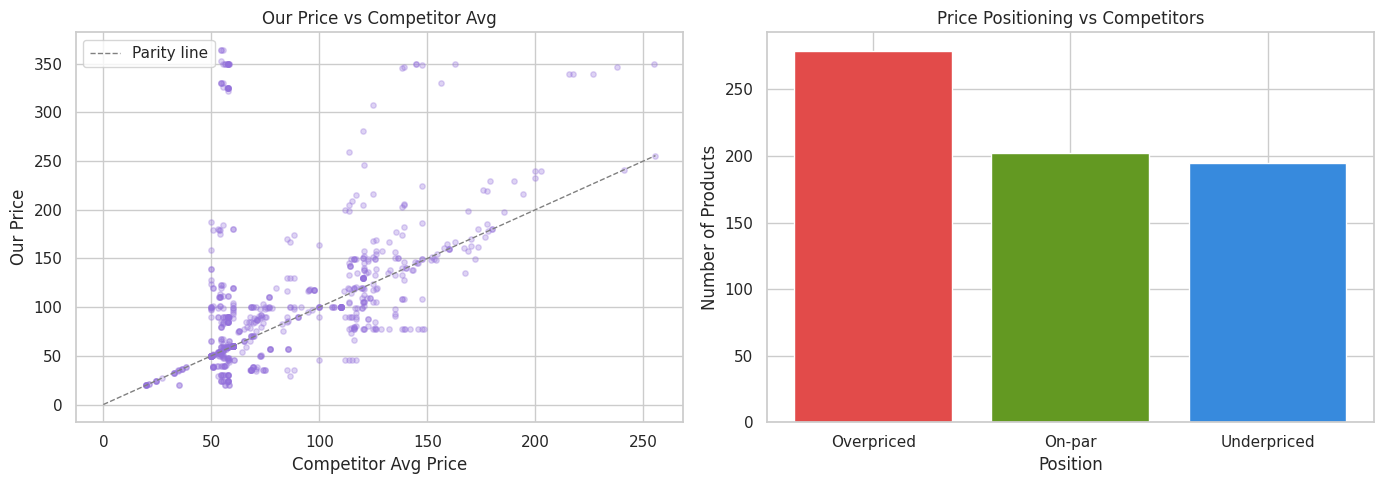

In [8]:
# Competitor Price Analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df['comp_avg'], df['unit_price'], alpha=0.3, color='mediumpurple', s=15)
axes[0].plot([0, df['comp_avg'].max()], [0, df['comp_avg'].max()],
             color='gray', linestyle='--', linewidth=1, label='Parity line')
axes[0].set_title('Our Price vs Competitor Avg')
axes[0].set_xlabel('Competitor Avg Price')
axes[0].set_ylabel('Our Price')
axes[0].legend()

pos_counts = df['price_position'].value_counts()
colors_map = {'Overpriced': '#E24B4A', 'On-par': '#639922', 'Underpriced': '#378ADD'}
axes[1].bar(pos_counts.index, pos_counts.values,
            color=[colors_map.get(x, 'gray') for x in pos_counts.index],
            edgecolor='white')
axes[1].set_title('Price Positioning vs Competitors')
axes[1].set_xlabel('Position')
axes[1].set_ylabel('Number of Products')

plt.tight_layout()
plt.savefig('competitor_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

=== Discount Band Summary ===
 discount_band  avg_revenue  avg_margin_pct  product_count
   No discount  1203.126269       72.214152            501
  Small (0–10)  1796.378585       74.974724            127
Medium (10–30)  2503.292783       82.440238             42
 Large (30–60)  3551.133742       88.708000              5
   Heavy (60+)  7620.719319       89.400000              1


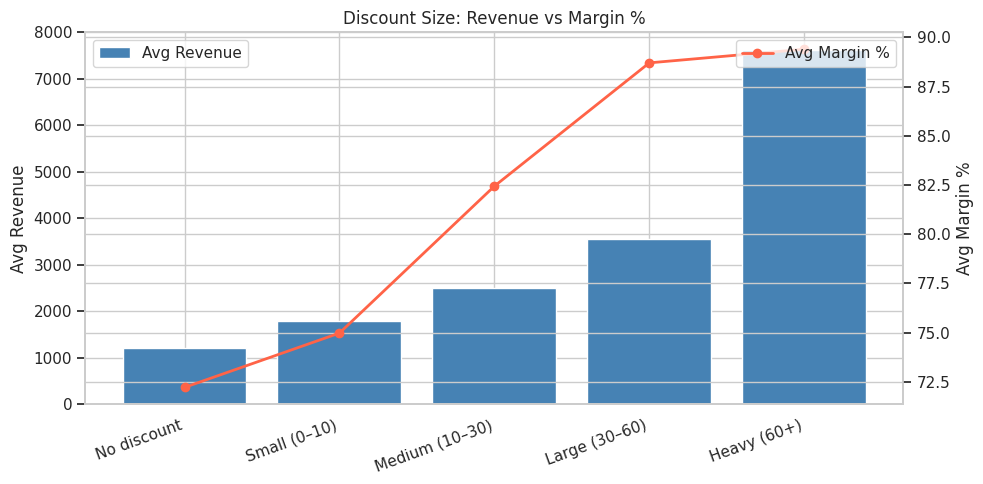

In [9]:
# Discount Impact — using lag_price as baseline
# lag_price = previous price → price drop = discount signal
df['price_drop'] = df['lag_price'] - df['unit_price']
df['discount_band'] = pd.cut(
    df['price_drop'],
    bins=[-9999, 0, 10, 30, 60, 9999],
    labels=['No discount', 'Small (0–10)', 'Medium (10–30)', 'Large (30–60)', 'Heavy (60+)']
)

discount_summary = df.groupby('discount_band', observed=True).agg(
    avg_revenue=('revenue', 'mean'),
    avg_margin_pct=('margin_pct', 'mean'),
    product_count=('unit_price', 'count')
).reset_index()

print("=== Discount Band Summary ===")
print(discount_summary.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
x = range(len(discount_summary))
ax.bar(x, discount_summary['avg_revenue'], color='steelblue', edgecolor='white', label='Avg Revenue')
ax2 = ax.twinx()
ax2.plot(x, discount_summary['avg_margin_pct'], color='tomato', marker='o', linewidth=2, label='Avg Margin %')
ax.set_xticks(x)
ax.set_xticklabels(discount_summary['discount_band'].astype(str), rotation=20, ha='right')
ax.set_title('Discount Size: Revenue vs Margin %')
ax.set_ylabel('Avg Revenue')
ax2.set_ylabel('Avg Margin %')
ax.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.tight_layout()
plt.savefig('discount_impact.png', dpi=150, bbox_inches='tight')
plt.show()

=== Top 5 Optimal Price Zones ===
 price_rounded  avg_revenue  avg_margin  score
           200  4308.615152   91.458333  0.982
           330  4170.862500   94.472500  0.980
           320  3935.388889   94.183333  0.943
           340  2554.438947   93.264211  0.732
           140  2815.482288   84.371852  0.717


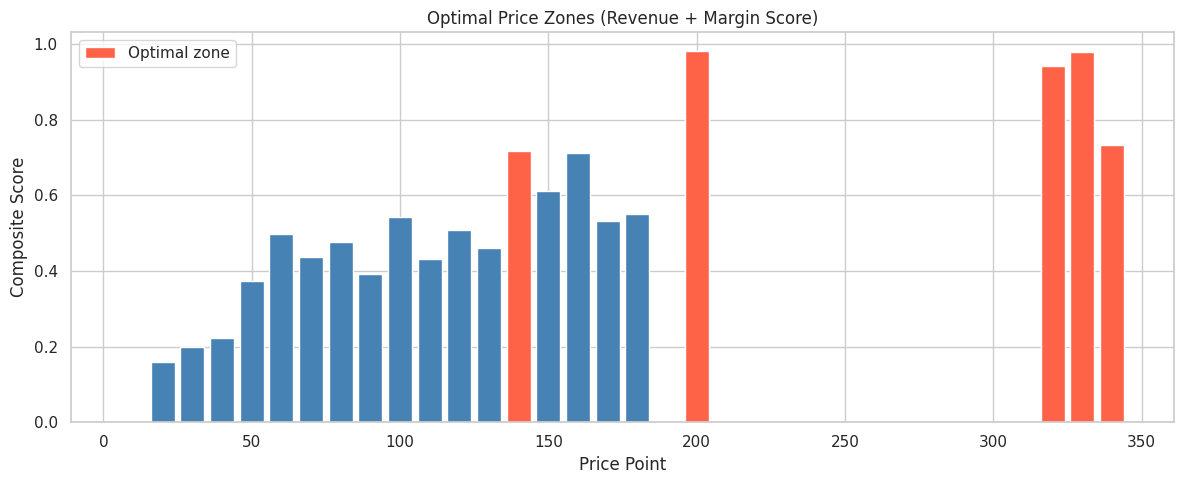

In [10]:
# Optimal Price Zone
df['price_rounded'] = (df['unit_price'] // 10 * 10).astype(int)
price_zone = df.groupby('price_rounded').agg(
    avg_revenue=('revenue', 'mean'),
    avg_margin=('margin_pct', 'mean'),
    count=('unit_price', 'count')
).reset_index()
price_zone = price_zone[price_zone['count'] >= 5]

price_zone['rev_norm'] = (price_zone['avg_revenue'] - price_zone['avg_revenue'].min()) / \
                          (price_zone['avg_revenue'].max() - price_zone['avg_revenue'].min())
price_zone['mar_norm'] = (price_zone['avg_margin'] - price_zone['avg_margin'].min()) / \
                          (price_zone['avg_margin'].max() - price_zone['avg_margin'].min())
price_zone['score'] = (0.6 * price_zone['rev_norm'] + 0.4 * price_zone['mar_norm']).round(3)

optimal = price_zone.sort_values('score', ascending=False).head(5)
print("=== Top 5 Optimal Price Zones ===")
print(optimal[['price_rounded', 'avg_revenue', 'avg_margin', 'score']].to_string(index=False))

plt.figure(figsize=(12, 5))
plt.bar(price_zone['price_rounded'], price_zone['score'], width=8,
        color='steelblue', edgecolor='white')
plt.bar(optimal['price_rounded'], optimal['score'], width=8,
        color='tomato', edgecolor='white', label='Optimal zone')
plt.title('Optimal Price Zones (Revenue + Margin Score)')
plt.xlabel('Price Point')
plt.ylabel('Composite Score')
plt.legend()
plt.tight_layout()
plt.savefig('optimal_price_zone.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
# Export for Tableau + Workbench
from google.colab import files

df.to_csv('pricing_analysis_clean.csv', index=False)
elast_df.to_csv('elasticity_by_category.csv', index=False)
price_zone.to_csv('optimal_price_zones.csv', index=False)
discount_summary.to_csv('discount_summary.csv', index=False)

files.download('pricing_analysis_clean.csv')
files.download('elasticity_by_category.csv')
files.download('optimal_price_zones.csv')
files.download('discount_summary.csv')

print("Done! 4 files downloaded. Ready for Tableau + Workbench.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! 4 files downloaded. Ready for Tableau + Workbench.
